# Paquetes

In [1]:
import pickle

from pennylane import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import OneHotEncoder

from src.convolutional import cnn, qcnn
from src.vis import plot_confusion_matrices,plot_ensemble_curve,plot_ensemble_patients, plot_kfold_distribution, plot_roc_curve

In [2]:
random_seed=42


# Carga de Datos

In [3]:
with open("data/nopi/train_imgs_tf.pkl", "rb") as f:
    train_imgs_tf = pickle.load(f)
with open("data/nopi/df_tr.pkl", "rb") as f:
    df_tr = pickle.load(f)

df_tr_rad = df_tr[df_tr["image_type"] == "radial"]
df_tr_circ = df_tr[df_tr["image_type"] == "circunferencial"]

train_imgs_tf_rad = train_imgs_tf[df_tr_rad.index]
train_imgs_tf_circ = train_imgs_tf[df_tr_circ.index]

with open("data/nopi/val_imgs_tf.pkl", "rb") as f:
    val_imgs_tf = pickle.load(f)
with open("data/nopi/df_val.pkl", "rb") as f:
    df_val = pickle.load(f)   

df_val_rad = df_val[df_val["image_type"] == "radial"]
df_val_circ = df_val[df_val["image_type"] == "circunferencial"]

val_imgs_tf_rad = val_imgs_tf[df_val_rad.index]
val_imgs_tf_circ = val_imgs_tf[df_val_circ.index]

with open("data/nopi/test_imgs_tf.pkl", "rb") as f:
    test_imgs_tf = pickle.load(f)
with open("data/nopi/df_test.pkl", "rb") as f:
    df_test = pickle.load(f)

df_test_rad = df_test[df_test["image_type"] == "radial"]
df_test_circ = df_test[df_test["image_type"] == "circunferencial"]

test_imgs_tf_rad = test_imgs_tf[df_test_rad.index]
test_imgs_tf_circ = test_imgs_tf[df_test_circ.index]

In [4]:
imgs_tf_rad = np.concatenate([train_imgs_tf_rad, val_imgs_tf_rad])
imgs_tf_circ = np.concatenate([train_imgs_tf_circ, val_imgs_tf_circ])

df_rad = pd.concat([df_tr_rad, df_val_rad], ignore_index=True)
df_circ = pd.concat([df_tr_circ, df_val_circ], ignore_index=True)

# Circuitos Cuánticos

In [5]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [6]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [7]:
q_train_images = load_data_to_cpu("quantum/nopi/train/train_{}.pkl", len(train_imgs_tf))
q_train_images_circ = q_train_images[df_tr_circ.index]
q_train_images_rad = q_train_images[df_tr_rad.index]
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum/nopi/validation/val_{}.pkl", len(val_imgs_tf))
q_val_images_circ = q_val_images[df_val_circ.index]
q_val_images_rad = q_val_images[df_val_rad.index]
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum/nopi/test/test_{}.pkl", len(test_imgs_tf))
q_test_images_circ = q_test_images[df_test_circ.index]
q_test_images_rad = q_test_images[df_test_rad.index]
print(q_test_images.shape)

q_images_rad = np.concatenate([q_train_images_rad, q_val_images_rad])
q_images_circ = np.concatenate([q_val_images_circ, q_train_images_circ])

(2784, 63, 63, 24)
(800, 63, 63, 24)
(416, 63, 63, 24)


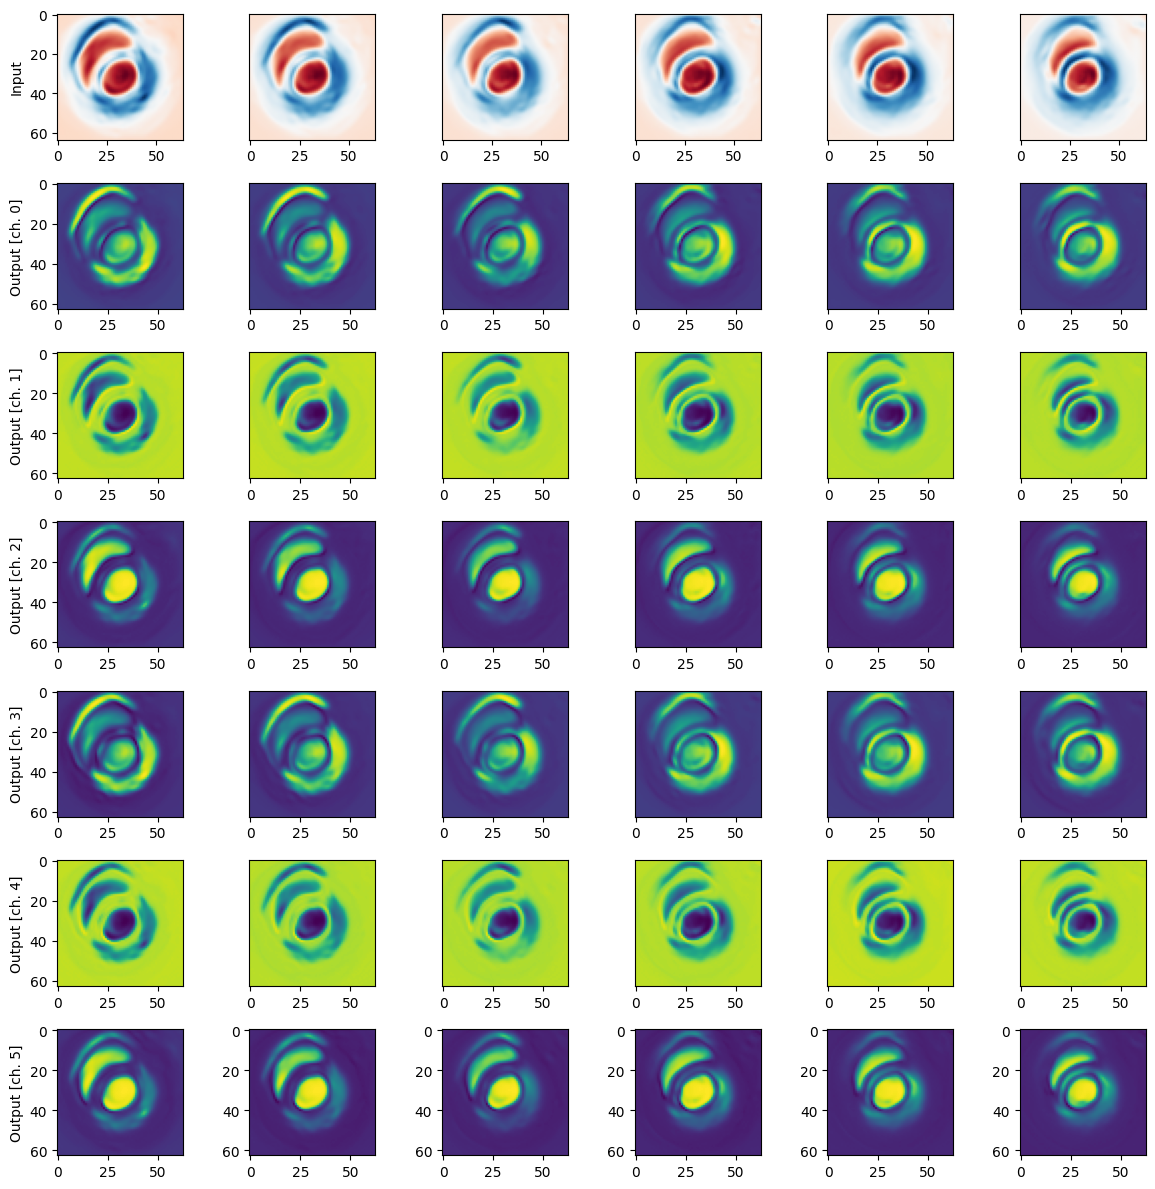

In [8]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf_rad[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images_rad[k, :, : ,c])

plt.tight_layout()
plt.show()

# Modelos básicos

In [9]:
class_names = ["C", "MCA"]

In [10]:
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True, verbose=1)

In [11]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images shape: {q_train_images.shape}')
print(f'q_val_images shape: {q_val_images.shape}')
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

q_train_images shape: (2784, 63, 63, 24)
q_val_images shape: (800, 63, 63, 24)
train_imgs_tf shape: (2784, 64, 64, 3)
val_imgs_tf shape: (800, 64, 64, 3)


In [12]:
# Train
mask_circ = ~df_tr_circ["class"].isin(["MU","MCD"])
df_tr2_circ = df_tr_circ[mask_circ]
train_imgs_tf2_circ = train_imgs_tf_circ[mask_circ]
q_train_images2_circ = q_train_images_circ[mask_circ]

mask_rad = ~df_tr_rad["class"].isin(["MU","MCD"])
df_tr2_rad = df_tr_rad[mask_rad]
train_imgs_tf2_rad = train_imgs_tf_rad[mask_rad]
q_train_images2_rad = q_train_images_rad[mask_rad]

# Validation
mask_circ = ~df_val_circ["class"].isin(["MU","MCD"])
df_val2_circ = df_val_circ[mask_circ]
val_imgs_tf2_circ = val_imgs_tf_circ[mask_circ]
q_val_images2_circ = q_val_images_circ[mask_circ]

mask_rad = ~df_val_rad["class"].isin(["MU","MCD"])
df_val2_rad = df_val_rad[mask_rad]
val_imgs_tf2_rad = val_imgs_tf_rad[mask_rad]
q_val_images2_rad = q_val_images_rad[mask_rad]

# KFolds
mask_circ = ~df_circ["class"].isin(["MU","MCD"])
df2_circ = df_circ[mask_circ]
imgs_tf2_circ = imgs_tf_circ[mask_circ]
q_images2_circ = q_images_circ[mask_circ]

mask_rad = ~df_rad["class"].isin(["MU","MCD"])
df2_rad = df_rad[mask_rad]
imgs_tf2_rad = imgs_tf_rad[mask_rad]
q_images2_rad = q_images_rad[mask_rad]

# Test
mask_circ = ~df_test_circ["class"].isin(["MU","MCD"])
df_test2_circ = df_test_circ[mask_circ]
test_imgs_tf2_circ = test_imgs_tf_circ[mask_circ]
q_test_images2_circ = q_test_images_circ[mask_circ]

mask_rad = ~df_test_rad["class"].isin(["MU","MCD"])
df_test2_rad = df_test_rad[mask_rad]
test_imgs_tf2_rad = test_imgs_tf_rad[mask_rad]
q_test_images2_rad = q_test_images_rad[mask_rad]

In [13]:
Encoder2=OneHotEncoder(sparse=False)
train_labels2_circ=Encoder2.fit_transform(df_tr2_circ["class"].values.reshape(-1, 1))
val_labels2_circ=Encoder2.fit_transform(df_val2_circ["class"].values.reshape(-1, 1))
test_labels2_circ=Encoder2.fit_transform(df_test2_circ["class"].values.reshape(-1, 1))
labels2_circ=Encoder2.fit_transform(df2_circ["class"].values.reshape(-1, 1))

train_labels2_rad=Encoder2.fit_transform(df_tr2_rad["class"].values.reshape(-1, 1))
val_labels2_rad=Encoder2.fit_transform(df_val2_rad["class"].values.reshape(-1, 1))
test_labels2_rad=Encoder2.fit_transform(df_test2_rad["class"].values.reshape(-1, 1))
labels2_rad=Encoder2.fit_transform(df2_rad["class"].values.reshape(-1, 1))

Encoder2.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was rename

[array(['C', 'MCA'], dtype=object)]

In [14]:
k=5
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)

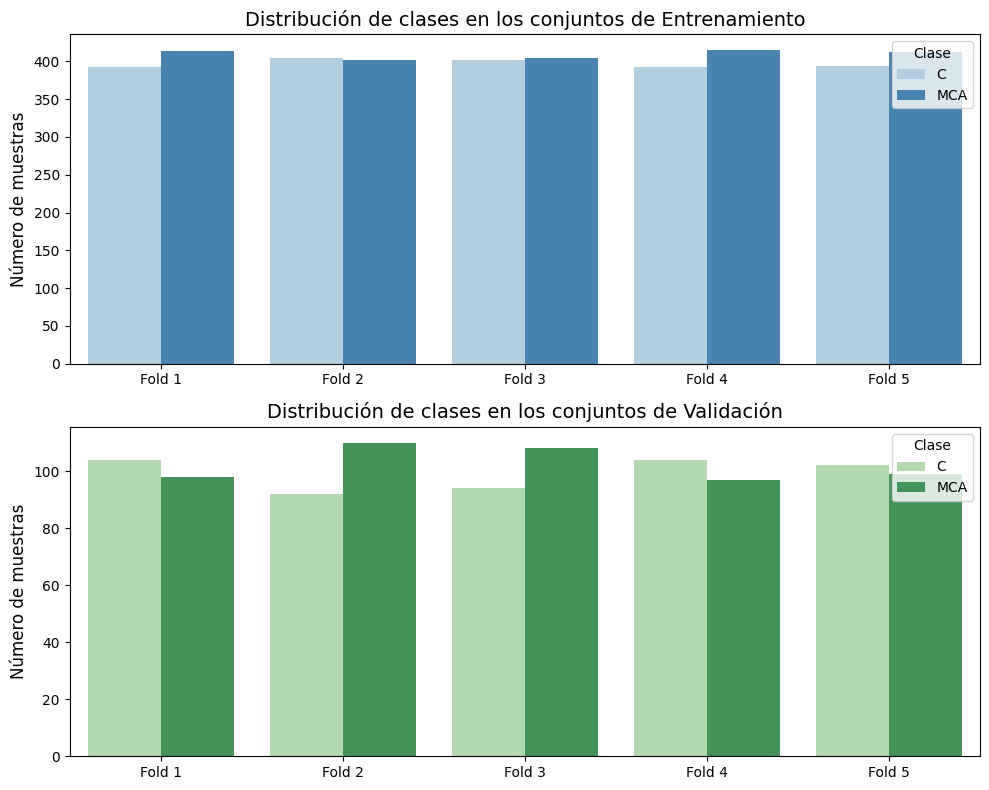

In [15]:
class_names = ["C", "MCA"]

# Inicializar KFold
plot_kfold_distribution(kf, df2_rad, class_names)

# Datos Radial

## QCNN

### KFold

In [ ]:
kf.get_n_splits(q_images2_rad,labels2_rad)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images2_rad[train_idx], q_images2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500


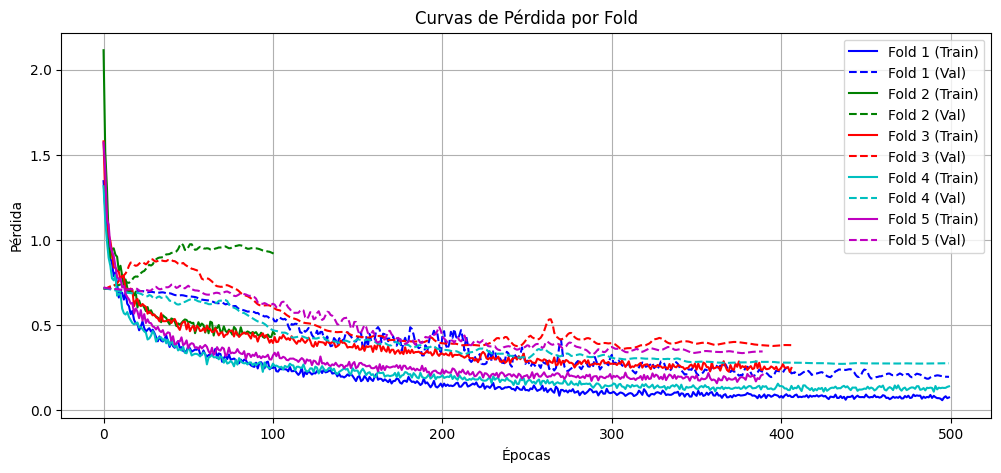

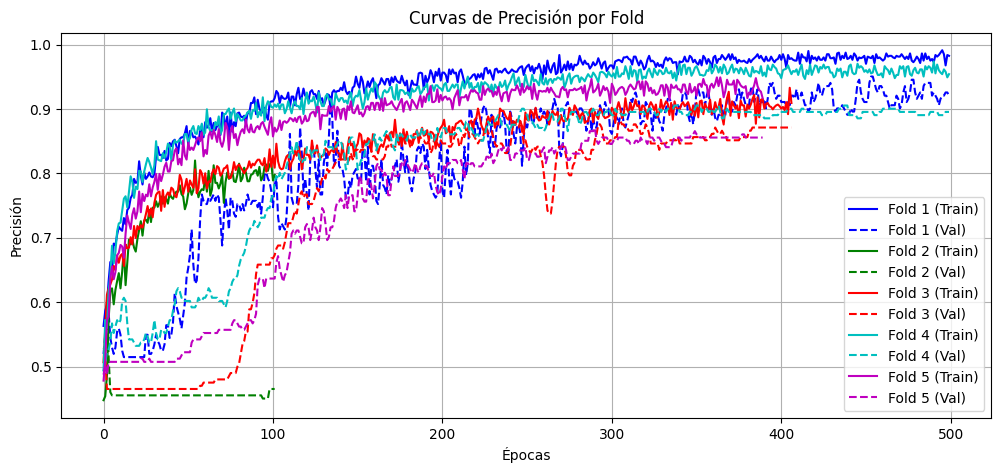

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

### Graficas

In [16]:
model_paths = [f"checkpoints/qcnn_fold{i+1}.h5" for i in range(5)]
history_paths = [f"history/qcnn_fold{i+1}.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

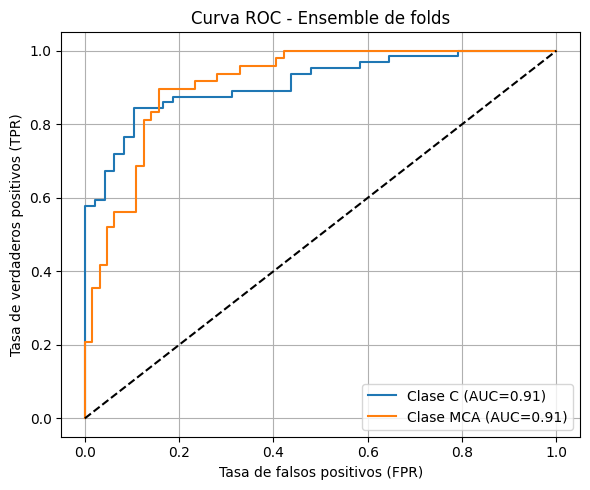

In [17]:
plot_roc_curve(q_test_images2_rad, test_labels2_rad, models, Encoder2)

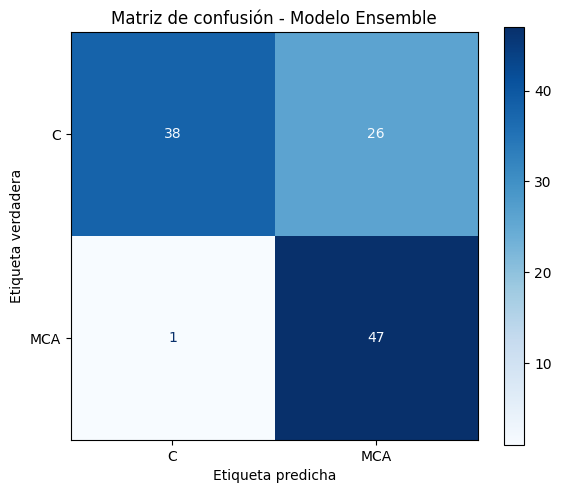

In [18]:
# Plot confusion matrices
plot_confusion_matrices(models, q_test_images2_rad, test_labels2_rad, class_names)

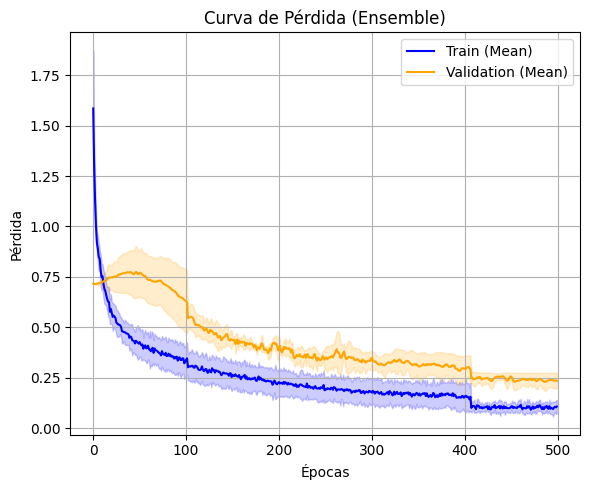

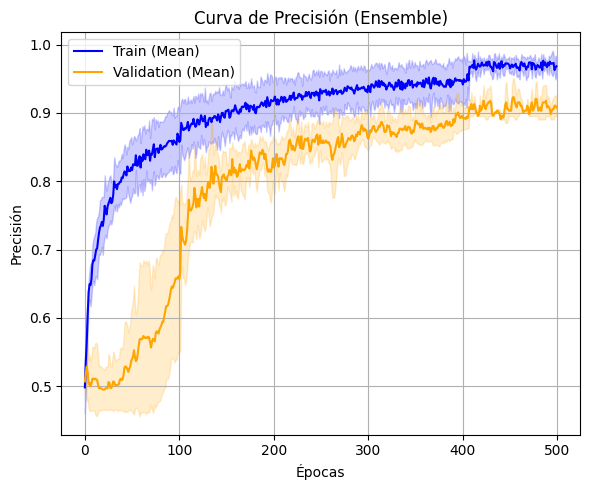

In [19]:
plot_ensemble_curve(histories)

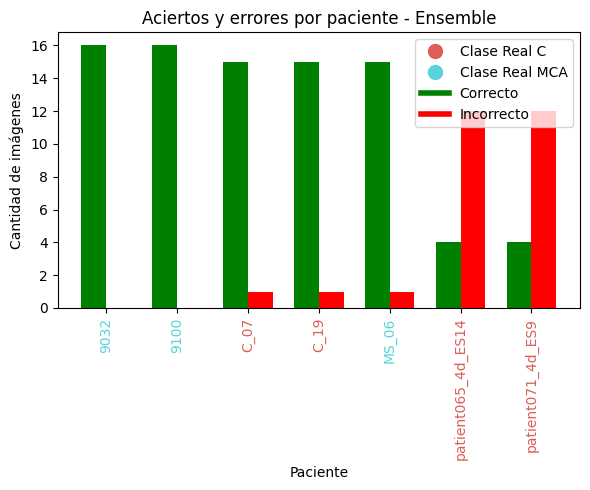

In [20]:
plot_ensemble_patients(models, histories, q_test_images2_rad, df_test2_rad, Encoder2)

## CNN

### KFold

In [ ]:
kf.get_n_splits(imgs_tf2_rad,labels2_rad)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf2_rad[train_idx], imgs_tf2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71630, saving model to checkpoints\cnn_fold1.h5
2/2 - 1s - loss: 1.2780 - accuracy: 0.5347 - val_loss: 0.7163 - val_accuracy: 0.5050 - lr: 0.0010 - 888ms/epoch - 444ms/step
Epoch 2/500

Epoch 2: val_loss did not improve from 0.71630
2/2 - 0s - loss: 1.2652 - accuracy: 0.5596 - val_loss: 0.7164 - val_accuracy: 0.4901 - lr: 0.0010 - 100ms/epoch - 50ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.71630 to 0.71486, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.1319 - accuracy: 0.5633 - val_loss: 0.7149 - val_accuracy: 0.5099 - lr: 0.0010 - 143ms/epoch - 71ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.71486 to 0.71351, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.0671 - accuracy: 0.6241 - val_loss: 0.7135 - val_accuracy: 0.5149 - lr: 0.0010 - 136ms/epoch - 68ms/step
Epoch 5/500

Epoch 5: val_loss improved from 0.71351 to 0.71230, saving model to checkpoints\cnn_fold1.h5


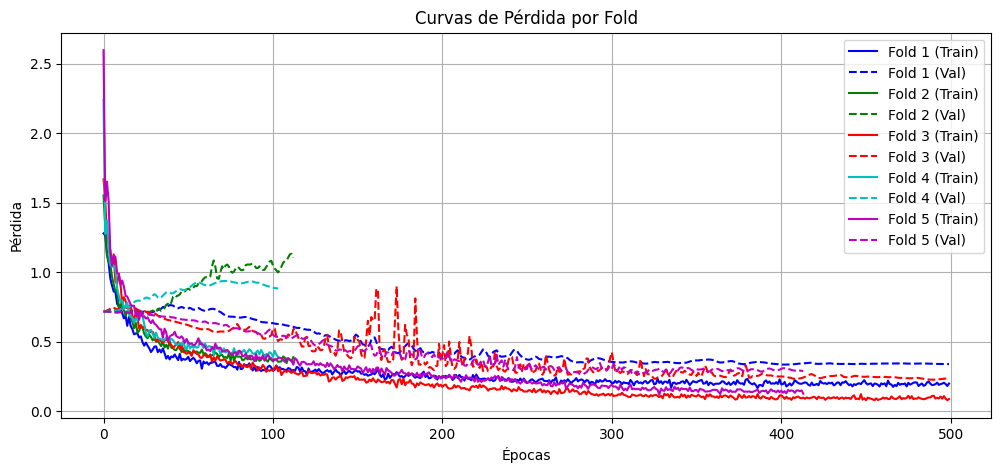

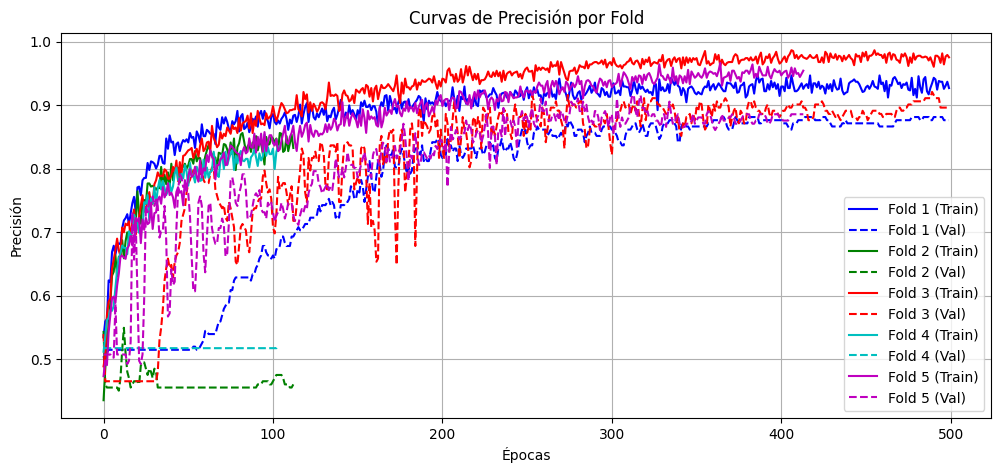

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

### Graficas

In [21]:
model_paths = [f"checkpoints/cnn_fold{i+1}.h5" for i in range(5)]
history_paths = [f"history/cnn_fold{i+1}.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

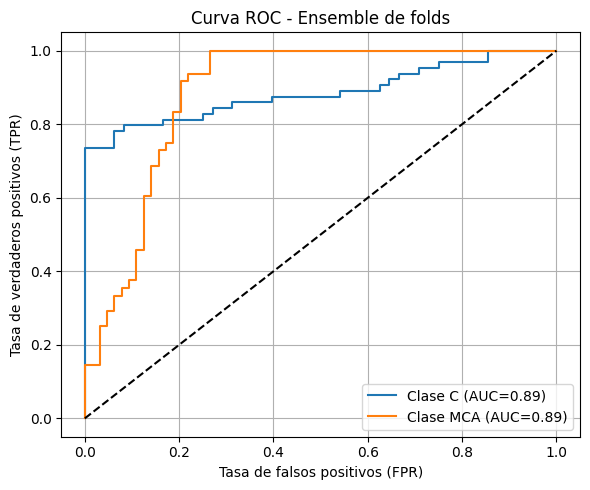

In [22]:
plot_roc_curve(test_imgs_tf2_rad, test_labels2_rad, models, Encoder2)

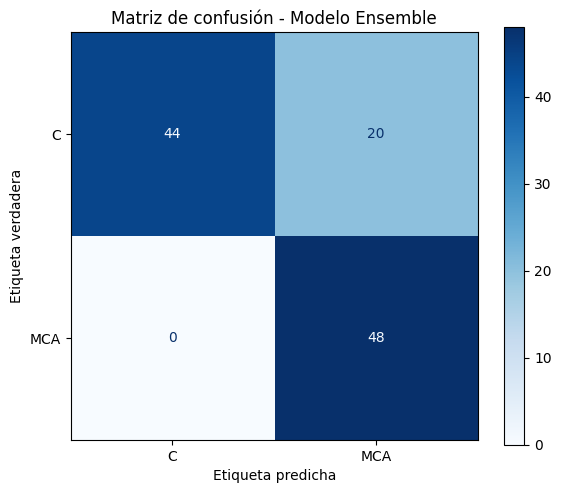

In [23]:
plot_confusion_matrices(models, test_imgs_tf2_rad, test_labels2_rad, class_names)

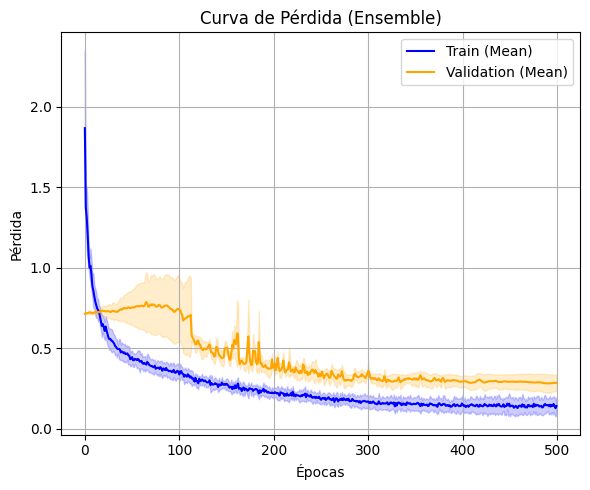

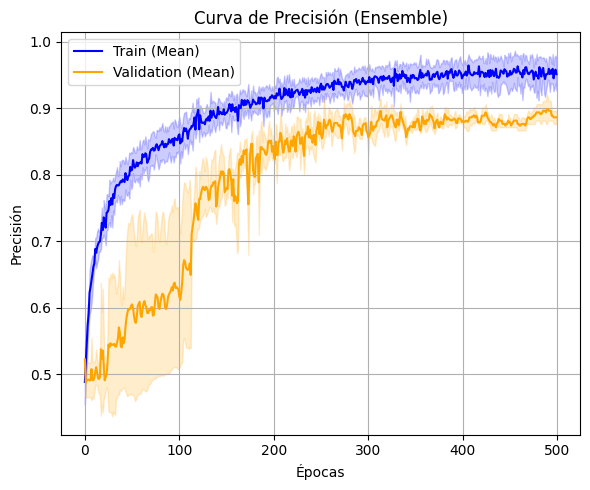

In [24]:
plot_ensemble_curve(histories)

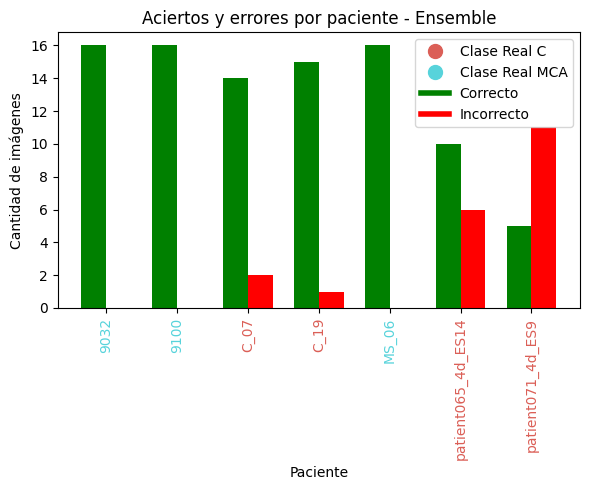

In [25]:
plot_ensemble_patients(models, histories, test_imgs_tf2_rad, df_test2_rad, Encoder2)

# Datos Circunferencial

## QCNN

### KFold

In [ ]:
kf.get_n_splits(q_images2_circ,labels2_circ)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images2_circ,labels2_circ)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images2_circ[train_idx], q_images2_circ[val_idx]
    train_labels, val_labels = labels2_circ[train_idx], labels2_circ[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}_circ.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}_circ.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71675, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 1s - loss: 1.4704 - accuracy: 0.5310 - val_loss: 0.7168 - val_accuracy: 0.4851 - lr: 0.0010 - 911ms/epoch - 455ms/step
Epoch 2/500

Epoch 2: val_loss improved from 0.71675 to 0.71548, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 0s - loss: 1.4583 - accuracy: 0.5099 - val_loss: 0.7155 - val_accuracy: 0.4901 - lr: 0.0010 - 151ms/epoch - 76ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.71548 to 0.71379, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 0s - loss: 1.2945 - accuracy: 0.5261 - val_loss: 0.7138 - val_accuracy: 0.4752 - lr: 0.0010 - 157ms/epoch - 79ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.71379 to 0.71211, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 0s - loss: 1.2386 - accuracy: 0.5546 - val_loss: 0.7121 - val_accuracy: 0.5743 - lr: 0.0010 - 161ms/epoch - 80ms/step
Epoch 5/500

Epoch 5: val_loss impro

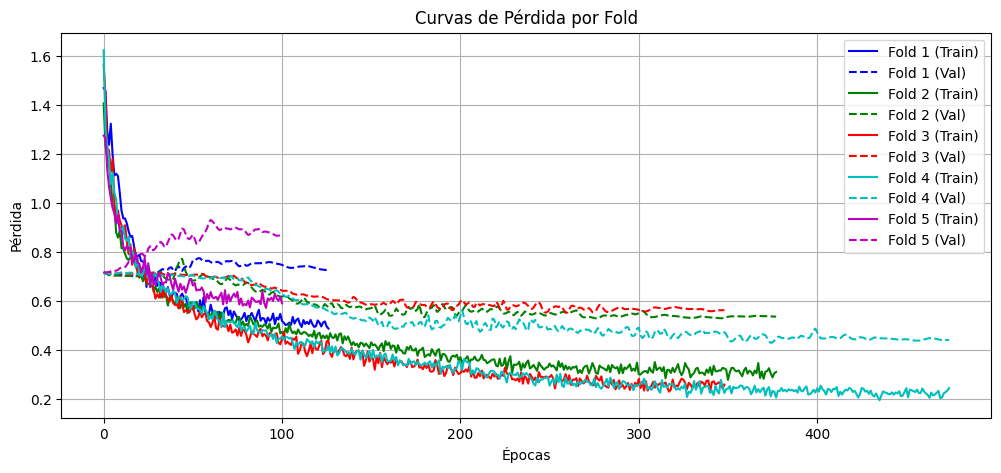

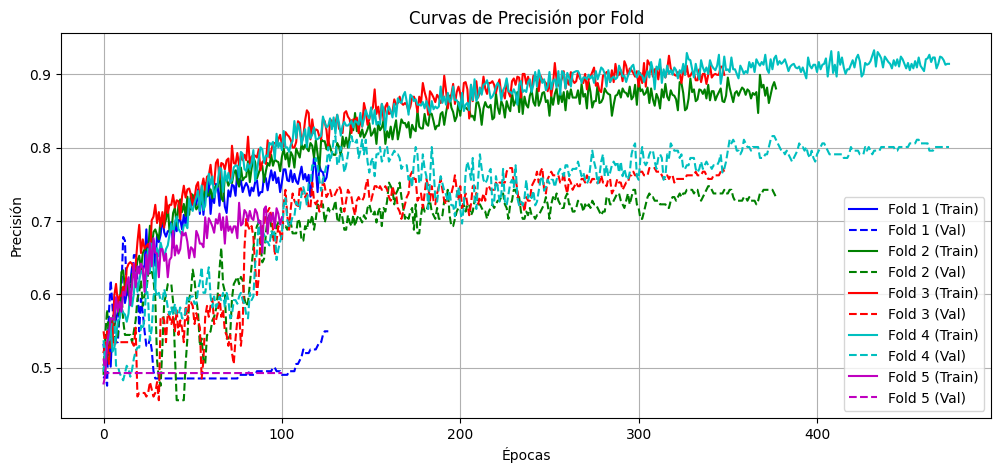

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

### Graficas

In [26]:
model_paths = [f"checkpoints/qcnn_fold{i+1}_circ.h5" for i in range(5)]
history_paths = [f"history/qcnn_fold{i+1}_circ.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

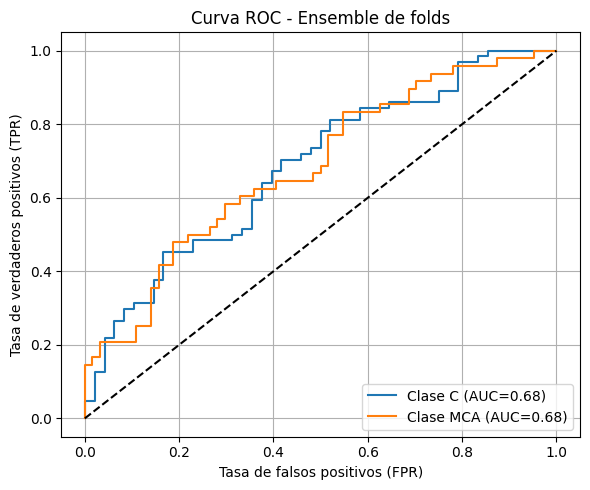

In [27]:
plot_roc_curve(q_test_images2_circ, test_labels2_circ, models, Encoder2)

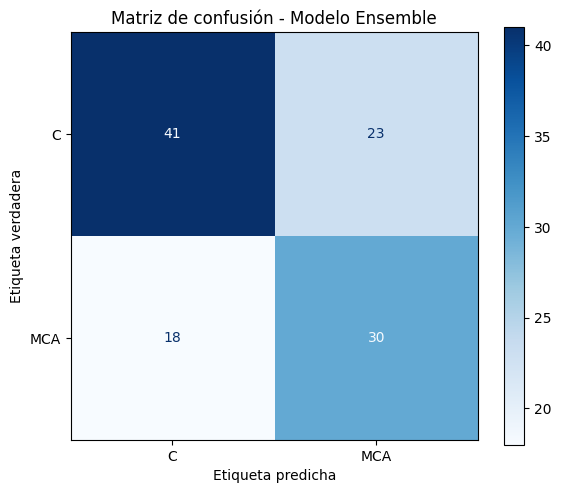

In [28]:
plot_confusion_matrices(models, q_test_images2_circ, test_labels2_circ, class_names)

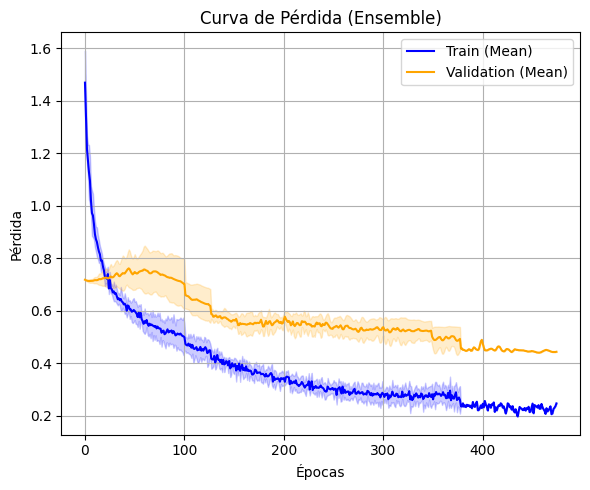

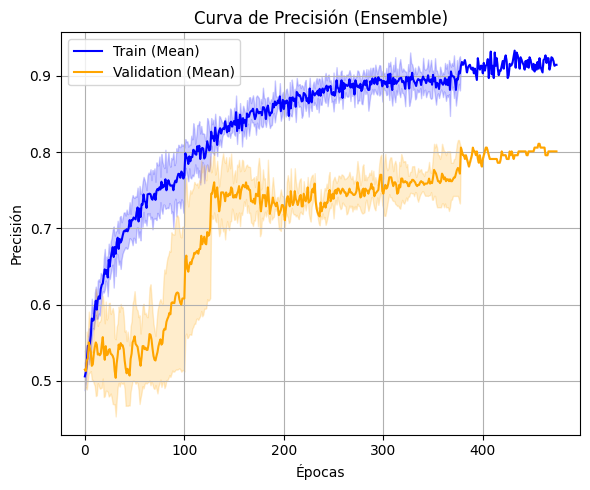

In [29]:
plot_ensemble_curve(histories)

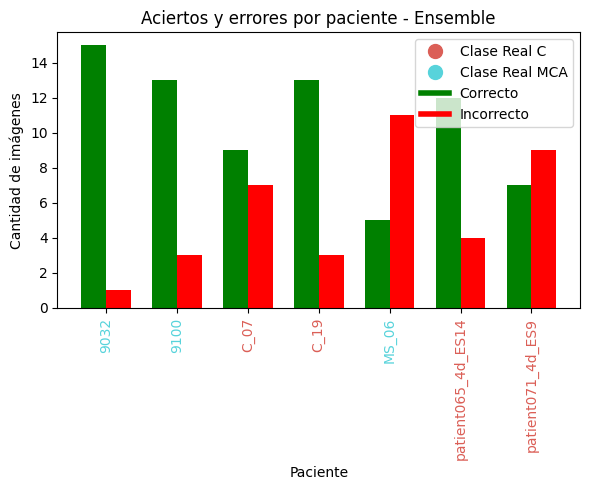

In [30]:
plot_ensemble_patients(models, histories, q_test_images2_rad, df_test2_rad, Encoder2)

## CNN

### KFold

In [ ]:
kf.get_n_splits(imgs_tf2_circ,labels2_circ)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf2_circ,labels2_circ)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf2_circ[train_idx], imgs_tf2_circ[val_idx]
    train_labels, val_labels = labels2_circ[train_idx], labels2_circ[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}_circ.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}_circ.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71423, saving model to checkpoints\cnn_fold1_circ.h5
2/2 - 1s - loss: 1.4695 - accuracy: 0.4851 - val_loss: 0.7142 - val_accuracy: 0.4950 - lr: 0.0010 - 744ms/epoch - 372ms/step
Epoch 2/500

Epoch 2: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.2136 - accuracy: 0.5037 - val_loss: 0.7161 - val_accuracy: 0.4851 - lr: 0.0010 - 106ms/epoch - 53ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.1435 - accuracy: 0.5670 - val_loss: 0.7176 - val_accuracy: 0.4851 - lr: 0.0010 - 102ms/epoch - 51ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.1440 - accuracy: 0.5496 - val_loss: 0.7184 - val_accuracy: 0.4851 - lr: 0.0010 - 101ms/epoch - 50ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.0767 - accuracy: 0.5149 - val_loss: 0.7179 - val_accuracy: 0.4851 - lr: 0.0010 - 102ms/epoch - 51ms/step
Epoch 6/5

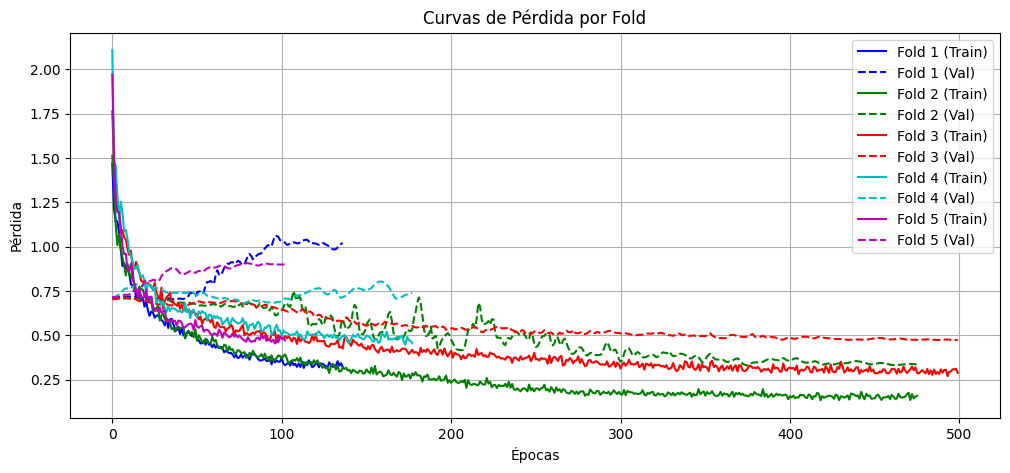

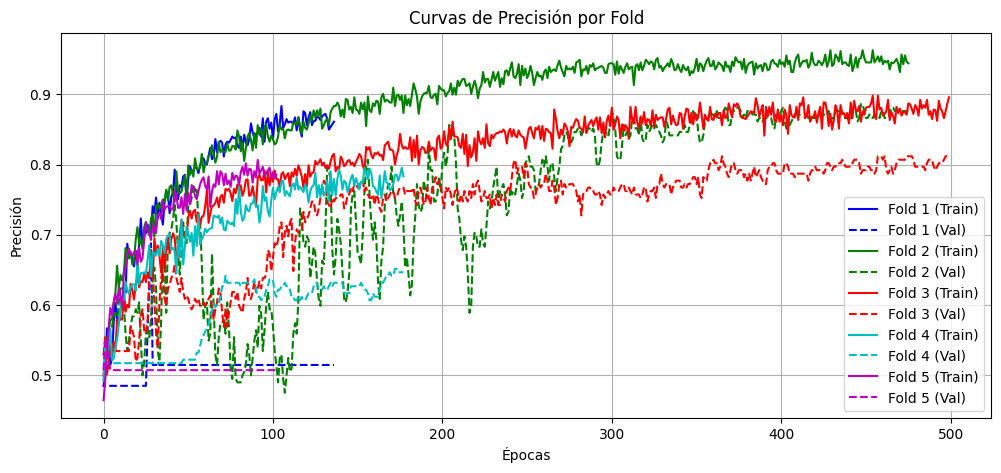

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

### Graficas

In [31]:
model_paths = [f"checkpoints/cnn_fold{i+1}_circ.h5" for i in range(5)]
history_paths = [f"history/cnn_fold{i+1}_circ.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

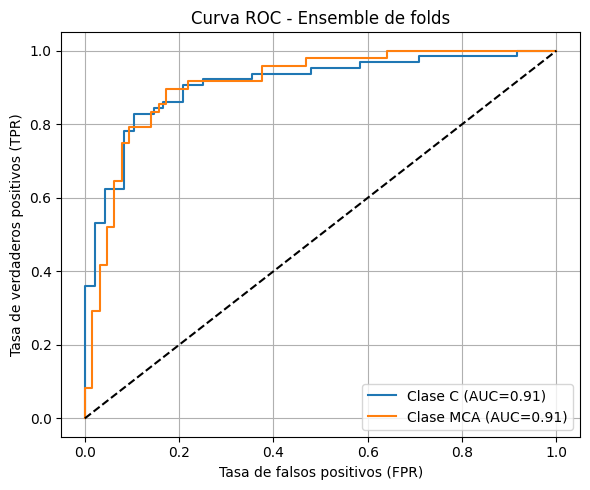

In [32]:
plot_roc_curve(test_imgs_tf2_circ, test_labels2_circ, models, Encoder2)

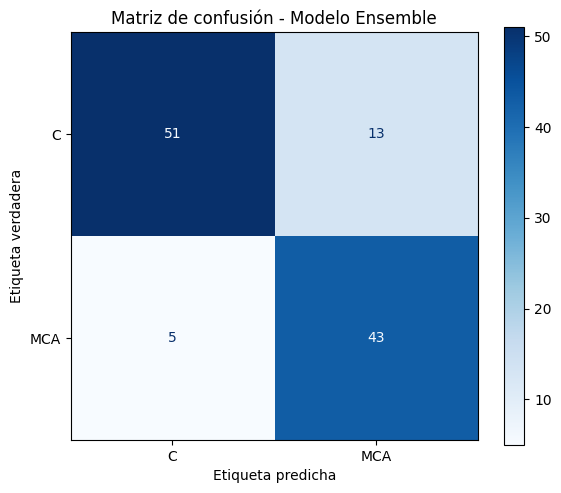

In [33]:
plot_confusion_matrices(models, test_imgs_tf2_circ, test_labels2_circ, class_names)

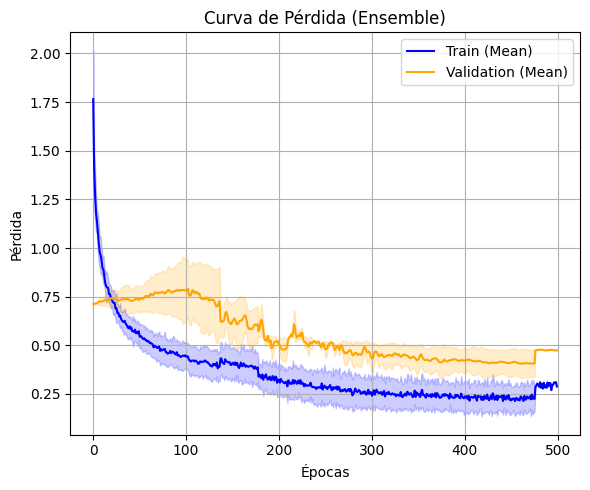

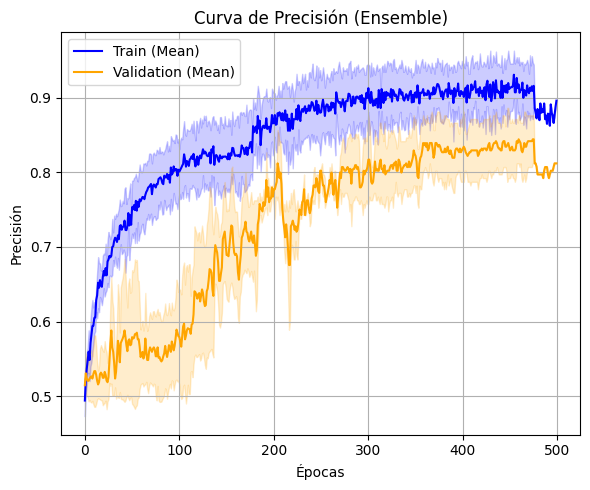

In [34]:
plot_ensemble_curve(histories)

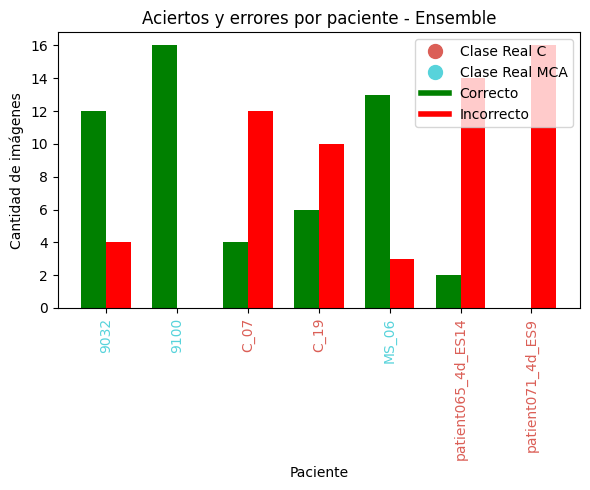

In [35]:
plot_ensemble_patients(models, histories, test_imgs_tf2_rad, df_test2_rad, Encoder2)